# Episode sampling

Goal: pick a representative subset of generated push episodes for downstream use.

Generator is noisy and produces three rough buckets:
- **positive** — robot pushes the object closer to the goal
- **negative** — robot pushes the object further from the goal
- **boring** — object barely moves

We want lots of positives, some negatives, a few boring ones.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rerun.experimental as rr_exp
import tqdm
from pathlib import Path

rng = np.random.default_rng(0)

## 1. Extract per-episode stats

Same extractors as `getting_started.ipynb` — kept self-contained here so the notebook stands alone.

In [2]:
# We bypass `rerun.server.Server` + DataFusion entirely because driving it
# from Python repeatedly in this version of rerun (0.32.1) raises
# `TaskContextProvider went out of scope over FFI boundary`. Instead we use
# the experimental chunk reader, which gives us Arrow record batches directly.

def _load_episode_arrays(path):
  """Return (object_xy[N,2], rewards[N or M,], goal_xy[2], outcome_str)."""
  store = rr_exp.RrdReader(str(path)).store()
  xy_steps, xy_vals, reward_vals = [], [], []
  goal_text = outcome_text = None
  for chunk in store.stream():
    ep = chunk.entity_path
    if ep == "/object_xy":
      rb = chunk.to_record_batch()
      xy_steps.extend(rb.column("step").to_pylist())
      xy_vals.extend(rb.column("Scalars:scalars").to_pylist())
    elif ep == "/reward":
      rb = chunk.to_record_batch()
      reward_vals.extend(rb.column("Scalars:scalars").to_pylist())
    elif ep == "/metadata/goal_xy":
      rb = chunk.to_record_batch()
      goal_text = rb.column("TextDocument:text")[0].as_py()
    elif ep == "/metadata/outcome":
      rb = chunk.to_record_batch()
      outcome_text = rb.column("TextDocument:text")[0].as_py()

  # `Scalars:scalars` rows are lists. object_xy is [x, y] per step; reward is
  # a single-element list per step. Sort xy by step in case chunks arrived
  # out of order (they shouldn't, but it's cheap insurance).
  order = np.argsort(xy_steps)
  xy = np.array([xy_vals[i] for i in order], dtype=float)        # (N, 2)
  rewards = np.array([r[0] for r in reward_vals], dtype=float)   # (M,)

  if isinstance(goal_text, list):
    goal_text = goal_text[0]
  if isinstance(outcome_text, list):
    outcome_text = outcome_text[0]
  goal_xy = np.array(
    [float(x) for x in goal_text.replace("[", "").replace("]", "").split(",")]
  )
  return xy, rewards, goal_xy, outcome_text


def process_one(path):
  xy, rewards, goal_xy, outcome = _load_episode_arrays(path)
  dists = np.linalg.norm(xy - goal_xy, axis=1)
  step_lens = np.linalg.norm(np.diff(xy, axis=0), axis=1)
  initial = float(dists[0])
  final = float(dists[-1])
  closest = float(np.min(dists))
  return {
    "filename": path.name,
    "path": str(path),
    "total_steps": len(xy),
    "max_reward": float(np.max(rewards)) if len(rewards) else float("nan"),
    "outcome": outcome,
    "initial_distance": initial,
    "final_distance": final,
    "distance_moved": float(np.sum(step_lens)),
    "net_progress": initial - final,                          # >0 closer, <0 further
    "closest_approach_fraction": 1.0 - (closest / initial) if initial > 0 else 0.0,
    "initial_position": xy[0],
    "goal_position": goal_xy,
  }

In [3]:
DATA_DIR = Path("../data/generated-pushes")
paths = sorted(DATA_DIR.glob("*.rrd"))
print(f"found {len(paths)} episodes")

rows, failed = [], []
for p in tqdm.tqdm(paths):
  try:
    rows.append(process_one(p))
  except Exception as e:
    failed.append((p.name, repr(e)))

print(f"loaded {len(rows)} / {len(paths)} episodes")
if failed:
  print(f"skipped {len(failed)}; first few:")
  for name, err in failed[:5]:
    print(f"  {name}: {err}")

assert rows, f"no episodes loaded. First error: {failed[0] if failed else 'unknown'}"
stats = pd.DataFrame(rows).sort_values("filename").reset_index(drop=True)
stats.head()

found 931 episodes


100%|██████████| 931/931 [02:58<00:00,  5.23it/s]


loaded 931 / 931 episodes


,filename,path,total_steps,max_reward,outcome,initial_distance,final_distance,distance_moved,net_progress,closest_approach_fraction,initial_position,goal_position
0,episode-00000.rrd,../data/generated-pushes/episode-00000.rrd,150,-0.207120,timeout,0.224920,0.213621,0.067275,0.011299,0.079141,"[-0.3188000023365021, 0.09600000083446503]","[-0.3655688464641571, -0.12400414794683456]"
1,episode-00001.rrd,../data/generated-pushes/episode-00001.rrd,150,-0.071603,timeout,0.106606,0.072219,0.052056,0.034386,0.328340,"[-0.34279999136924744, -0.024800000712275505]","[-0.32928135991096497, -0.1305452436208725]"
2,episode-00002.rrd,../data/generated-pushes/episode-00002.rrd,150,-0.103355,timeout,0.103355,0.103355,0.000000,0.000000,0.000000,"[-0.37049999833106995, -0.05920000001788139]","[-0.33224594593048096, -0.1552148014307022]"
3,episode-00003.rrd,../data/generated-pushes/episode-00003.rrd,150,-0.149144,timeout,0.204040,0.153484,0.096991,0.050556,0.269048,"[-0.3797000050544739, 0.02800000086426735]","[-0.3542190492153168, -0.17444293200969696]"
4,episode-00004.rrd,../data/generated-pushes/episode-00004.rrd,150,-0.104386,timeout,0.104386,0.104386,0.000000,0.000000,0.000000,"[-0.39959999918937683, -0.09130000323057175]","[-0.35928189754486084, -0.18758524954319]"


## 2. Categorize episodes

We split each episode into one of:
- **boring** — object hardly moved (`distance_moved` below a small threshold)
- **positive** — net progress toward goal is meaningful
- **negative** — net progress is meaningfully away from goal
- **neutral** — moved but ended up about where it started (we ignore these for sampling)

Thresholds are relative to the empirical distribution so they adapt if you regenerate the data.

In [4]:
# Boring: bottom 25% of total path length traveled.
BORING_MOVED_PCTL = 25
boring_thresh = np.percentile(stats["distance_moved"], BORING_MOVED_PCTL)

# Progress threshold: 10% of median initial distance — i.e. the object actually
# crossed an interesting fraction of the table toward (or away from) the goal.
PROGRESS_THRESH = 0.10 * np.median(stats["initial_distance"])

def categorize(row):
  if row["distance_moved"] < boring_thresh:
    return "boring"
  if row["net_progress"] > PROGRESS_THRESH:
    return "positive"
  if row["net_progress"] < -PROGRESS_THRESH:
    return "negative"
  return "neutral"

stats["category"] = stats.apply(categorize, axis=1)
print(f"boring threshold (distance_moved < {boring_thresh:.4f})")
print(f"progress threshold (|net_progress| > {PROGRESS_THRESH:.4f})")
print(stats["category"].value_counts())

boring threshold (distance_moved < 0.0521)
progress threshold (|net_progress| > 0.0194)
category
positive    424
boring      233
neutral     221
negative     53
Name: count, dtype: int64


## 3. Sample

Mix favors positives. Within positives we stratify by `net_progress` so we get both modest pushes and big wins. Negatives are sampled across the range so we don't only get catastrophic failures. Boring picks are random.

In [5]:
TARGET = {"positive": 40, "negative": 15, "boring": 5}
MIN_STEPS = 20  # very short episodes are not useful regardless of outcome

eligible = stats[stats["total_steps"] >= MIN_STEPS]
print(f"eligible after min-steps filter: {len(eligible)} / {len(stats)} "
      f"(dropped {len(stats) - len(eligible)} with < {MIN_STEPS} steps)")
print(eligible["category"].value_counts())

def stratified_sample(df, n, by, n_bins=4):
  """Split `df` into `n_bins` quantile bins of `by` and sample roughly evenly."""
  if len(df) <= n:
    return df
  bins = pd.qcut(df[by], q=min(n_bins, len(df)), duplicates="drop")
  per_bin = max(1, n // bins.nunique())
  picked = (
    df.groupby(bins, group_keys=False, observed=True)
      .apply(lambda g: g.sample(min(len(g), per_bin), random_state=rng.integers(1 << 31)))
  )
  # Top up randomly if we under-shot due to integer division.
  if len(picked) < n:
    rest = df.drop(picked.index)
    extra = rest.sample(min(len(rest), n - len(picked)), random_state=rng.integers(1 << 31))
    picked = pd.concat([picked, extra])
  return picked.head(n)

pos = eligible[eligible["category"] == "positive"]
neg = eligible[eligible["category"] == "negative"]
bor = eligible[eligible["category"] == "boring"]

sampled = pd.concat([
  stratified_sample(pos, TARGET["positive"], "net_progress"),
  stratified_sample(neg, TARGET["negative"], "net_progress"),
  bor.sample(min(len(bor), TARGET["boring"]), random_state=0),
]).reset_index(drop=True)

print(sampled["category"].value_counts())
sampled[["filename", "category", "total_steps", "initial_distance", "final_distance", "net_progress", "distance_moved"]].head(20)

eligible after min-steps filter: 931 / 931 (dropped 0 with < 20 steps)
category
positive    424
boring      233
neutral     221
negative     53
Name: count, dtype: int64
category
positive    40
negative    15
boring       5
Name: count, dtype: int64


,filename,category,total_steps,initial_distance,final_distance,net_progress,distance_moved
0,episode-00313.rrd,positive,150,0.149535,0.129907,0.019628,0.084608
1,episode-00660.rrd,positive,150,0.203459,0.179386,0.024073,0.074978
2,episode-00277.rrd,positive,150,0.226878,0.199312,0.027566,0.080919
3,episode-00661.rrd,positive,150,0.208191,0.183940,0.024251,0.056433
4,episode-00387.rrd,positive,150,0.145839,0.119505,0.026335,0.127670
5,episode-00951.rrd,positive,150,0.227964,0.200476,0.027488,0.057087
6,episode-00083.rrd,positive,150,0.278296,0.258466,0.019829,0.055560
7,episode-00644.rrd,positive,150,0.265843,0.238474,0.027369,0.076683
8,episode-00846.rrd,positive,150,0.123407,0.102949,0.020458,0.078283
9,episode-00870.rrd,positive,150,0.136308,0.108243,0.028065,0.066334


In [6]:
def sample_split(sizes, *, ratios=TARGET, min_steps=MIN_STEPS):
  """Create disjoint samples of the given sizes, each with the same category mix.

  sizes:   iterable of ints, e.g. [60, 20] for a train and eval set.
  ratios:  dict like TARGET — relative weights per category. Defaults to TARGET.
  Returns a list of DataFrames, one per entry in `sizes`. Samples never overlap.
  Within each category, positive/negative are stratified across net_progress;
  boring is uniform random.

  If a category is too small for the requested target ratio, its weight is
  reduced to whatever is feasible and the other categories' weights are
  rescaled to absorb the slack. Each output set still hits its full requested
  size, and all sets share the (possibly adjusted) mix.
  """
  pool = stats[stats["total_steps"] >= min_steps]
  available = {cat: int((pool["category"] == cat).sum()) for cat in ratios}
  total_size = sum(sizes)

  # Find a ratio that fits: cap any over-requested category to its supply,
  # then rescale the remaining weights to bring the total back to 1.
  # Iterate because capping one category can push another over its limit.
  weights = {c: w / sum(ratios.values()) for c, w in ratios.items()}
  capped = set()
  while True:
    needed = {c: weights[c] * total_size for c in ratios}
    over = [c for c in ratios if c not in capped and needed[c] > available[c]]
    if not over:
      break
    for c in over:
      # Lock this category to exactly its supply.
      weights[c] = available[c] / total_size
      capped.add(c)
    free_total = 1 - sum(weights[c] for c in capped)
    free_orig = sum(ratios[c] for c in ratios if c not in capped)
    if free_orig == 0 or free_total <= 0:
      break
    for c in ratios:
      if c not in capped:
        weights[c] = free_total * ratios[c] / free_orig

  adjusted = {c: round(weights[c] * sum(ratios.values()), 2) for c in ratios}
  if adjusted != {c: float(ratios[c]) for c in ratios}:
    print(f"adjusted mix: {ratios} -> weights {adjusted} "
          f"(capacity: {available})")

  # Largest-remainder allocation per set using the (possibly adjusted) weights.
  def allocate(size):
    raw = {c: size * weights[c] for c in ratios}
    base = {c: int(np.floor(v)) for c, v in raw.items()}
    remainder = size - sum(base.values())
    # Hand out leftovers to categories with the largest fractional parts,
    # but skip those already at supply capacity.
    candidates = sorted(
      [(c, raw[c] - base[c]) for c in ratios],
      key=lambda kv: kv[1], reverse=True,
    )
    for c, _ in candidates:
      if remainder == 0:
        break
      # We may not exceed `available[c]` across all sets; tracked outside.
      base[c] += 1
      remainder -= 1
    return base

  per_set_counts = [allocate(s) for s in sizes]
  needed = {c: sum(s[c] for s in per_set_counts) for c in ratios}

  # If rounding pushed any category above supply, peel one slot back from the
  # set with the smallest fractional remainder until we fit.
  for c in ratios:
    while needed[c] > available[c]:
      i = max(range(len(sizes)), key=lambda i: per_set_counts[i][c])
      per_set_counts[i][c] -= 1
      needed[c] -= 1
      # Move that slot to a category with spare capacity.
      donors = [d for d in ratios if needed[d] < available[d]]
      if donors:
        donor = max(donors, key=lambda d: weights[d])
        per_set_counts[i][donor] += 1
        needed[donor] += 1

  # Draw the full per-category allocation once, then slice into the output sets
  # so the splits are disjoint without re-rolling.
  results = [[] for _ in sizes]
  for c in ratios:
    n_cat = needed[c]
    if n_cat == 0:
      continue
    cat_pool = pool[pool["category"] == c]
    if c in ("positive", "negative"):
      drawn = stratified_sample(cat_pool, n_cat, "net_progress")
    else:
      drawn = cat_pool.sample(n_cat, random_state=rng.integers(1 << 31))
    drawn = drawn.sample(frac=1, random_state=rng.integers(1 << 31))
    cursor = 0
    for i, counts in enumerate(per_set_counts):
      k = counts[c]
      results[i].append(drawn.iloc[cursor:cursor + k])
      cursor += k

  return [pd.concat(parts).reset_index(drop=True) if parts else pd.DataFrame()
          for parts in results]


# Example: a 60-episode train set and a 20-episode eval set, same distribution.
train, evalset = sample_split([60, 20])
print("train:", train["category"].value_counts().to_dict(), " size:", len(train))
print("eval :", evalset["category"].value_counts().to_dict(), " size:", len(evalset))
assert set(train["filename"]).isdisjoint(set(evalset["filename"])), "overlap!"

train: {'positive': 40, 'negative': 15, 'boring': 5}  size: 60
eval : {'positive': 13, 'negative': 5, 'boring': 2}  size: 20


## 4. Sampled filenames

In [7]:
for cat in ["positive", "negative", "boring"]:
  sub = sampled[sampled["category"] == cat]
  print(f"\n=== {cat}  (n={len(sub)}) ===")
  for _, r in sub.sort_values("net_progress", ascending=False).iterrows():
    print(f"  {r['filename']:24s}  init={r['initial_distance']:.3f}  "
          f"final={r['final_distance']:.3f}  net={r['net_progress']:+.3f}  "
          f"moved={r['distance_moved']:.3f}")

# Also dump a flat list (handy for copy-paste into a config).
sampled["filename"].tolist()


=== positive  (n=40) ===
  episode-00792.rrd         init=0.184  final=0.097  net=+0.087  moved=0.151
  episode-00270.rrd         init=0.213  final=0.140  net=+0.073  moved=0.133
  episode-00710.rrd         init=0.195  final=0.126  net=+0.069  moved=0.105
  episode-00574.rrd         init=0.115  final=0.049  net=+0.066  moved=0.084
  episode-00737.rrd         init=0.141  final=0.082  net=+0.059  moved=0.088
  episode-00501.rrd         init=0.232  final=0.176  net=+0.056  moved=0.101
  episode-00805.rrd         init=0.214  final=0.160  net=+0.054  moved=0.162
  episode-00533.rrd         init=0.149  final=0.096  net=+0.053  moved=0.095
  episode-00347.rrd         init=0.171  final=0.120  net=+0.051  moved=0.104
  episode-00612.rrd         init=0.203  final=0.154  net=+0.050  moved=0.098
  episode-00254.rrd         init=0.183  final=0.135  net=+0.049  moved=0.067
  episode-00993.rrd         init=0.176  final=0.129  net=+0.047  moved=0.097
  episode-00659.rrd         init=0.128  final=0.08

['episode-00313.rrd',
 'episode-00660.rrd',
 'episode-00277.rrd',
 'episode-00661.rrd',
 'episode-00387.rrd',
 'episode-00951.rrd',
 'episode-00083.rrd',
 'episode-00644.rrd',
 'episode-00846.rrd',
 'episode-00870.rrd',
 'episode-00093.rrd',
 'episode-00339.rrd',
 'episode-00420.rrd',
 'episode-00363.rrd',
 'episode-00645.rrd',
 'episode-00582.rrd',
 'episode-00050.rrd',
 'episode-00049.rrd',
 'episode-00166.rrd',
 'episode-00488.rrd',
 'episode-00886.rrd',
 'episode-00296.rrd',
 'episode-00340.rrd',
 'episode-00254.rrd',
 'episode-00449.rrd',
 'episode-00993.rrd',
 'episode-00692.rrd',
 'episode-00659.rrd',
 'episode-00117.rrd',
 'episode-00356.rrd',
 'episode-00347.rrd',
 'episode-00710.rrd',
 'episode-00737.rrd',
 'episode-00501.rrd',
 'episode-00533.rrd',
 'episode-00805.rrd',
 'episode-00574.rrd',
 'episode-00270.rrd',
 'episode-00792.rrd',
 'episode-00612.rrd',
 'episode-00246.rrd',
 'episode-00128.rrd',
 'episode-00966.rrd',
 'episode-00849.rrd',
 'episode-00557.rrd',
 'episode-

In [8]:
# Persist the sample so downstream scripts can read it.
out_path = Path("../data/sampled_episodes.csv")
sampled[["filename", "path", "category", "initial_distance", "final_distance",
         "net_progress", "distance_moved", "closest_approach_fraction",
         "max_reward", "total_steps", "outcome"]].to_csv(out_path, index=False)
print(f"wrote {out_path}")

wrote ../data/sampled_episodes.csv


## 5. Statistics & plots

Compare the sampled subset against the full dataset.

In [9]:
def summarize(df):
  return pd.Series({
    "n": len(df),
    "init_dist (median)": df["initial_distance"].median(),
    "final_dist (median)": df["final_distance"].median(),
    "net_progress (mean)": df["net_progress"].mean(),
    "net_progress (median)": df["net_progress"].median(),
    "distance_moved (median)": df["distance_moved"].median(),
    "max_reward (median)": df["max_reward"].median(),
  })

summary = pd.concat({
  "all":      summarize(stats),
  "sampled":  summarize(sampled),
  "positive": summarize(sampled[sampled.category == "positive"]),
  "negative": summarize(sampled[sampled.category == "negative"]),
  "boring":   summarize(sampled[sampled.category == "boring"]),
}, axis=1).round(4)
summary

,all,sampled,positive,negative,boring
n,931.0000,60.0000,40.0000,15.0000,5.0000
init_dist (median),0.1943,0.2103,0.2024,0.2238,0.1449
final_dist (median),0.1723,0.1796,0.1569,0.2556,0.1394
net_progress (mean),0.0210,0.0182,0.0407,-0.0365,0.0017
net_progress (median),0.0203,0.0294,0.0375,-0.0380,0.0000
distance_moved (median),0.0709,0.0805,0.0796,0.0948,0.0000
max_reward (median),-0.1674,-0.1725,-0.1531,-0.2238,-0.1389


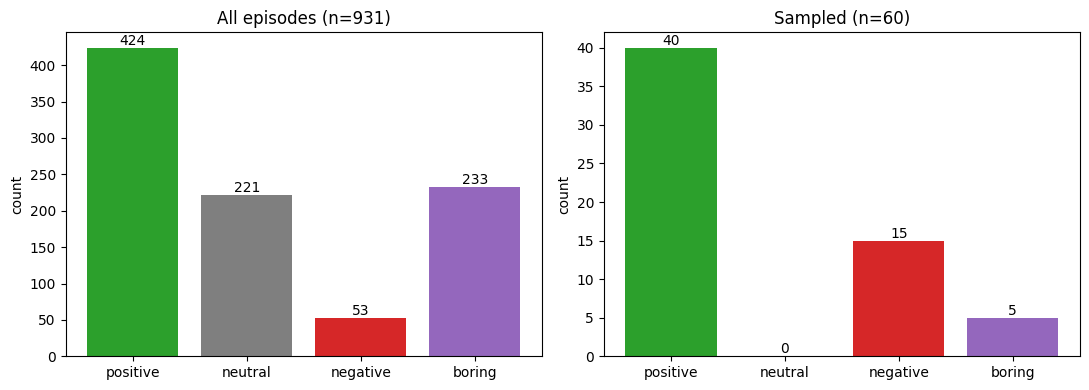

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

order = ["positive", "neutral", "negative", "boring"]
colors = {"positive": "#2ca02c", "neutral": "#7f7f7f", "negative": "#d62728", "boring": "#9467bd"}

all_counts = stats["category"].value_counts().reindex(order, fill_value=0)
samp_counts = sampled["category"].value_counts().reindex(order, fill_value=0)

axes[0].bar(order, all_counts.values, color=[colors[c] for c in order])
axes[0].set_title(f"All episodes (n={len(stats)})")
axes[0].set_ylabel("count")
for i, v in enumerate(all_counts.values):
  axes[0].text(i, v, str(v), ha="center", va="bottom")

axes[1].bar(order, samp_counts.values, color=[colors[c] for c in order])
axes[1].set_title(f"Sampled (n={len(sampled)})")
axes[1].set_ylabel("count")
for i, v in enumerate(samp_counts.values):
  axes[1].text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

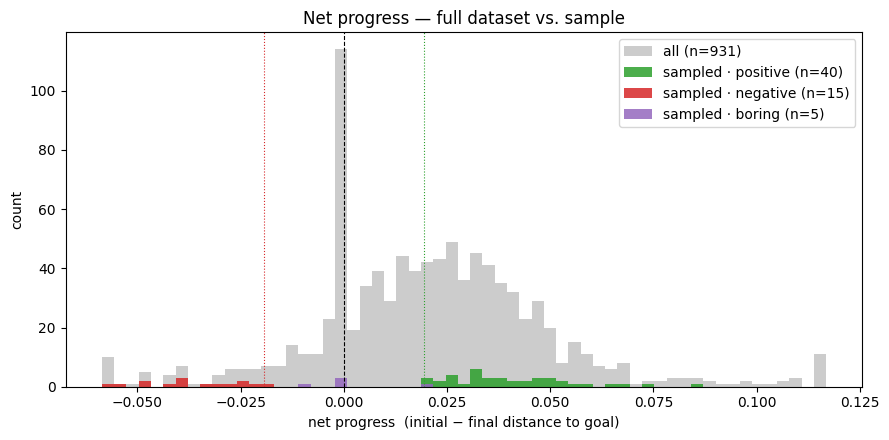

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))

lo, hi = np.percentile(stats["net_progress"], [1, 99])
bins = np.linspace(lo, hi, 60)

ax.hist(stats["net_progress"].clip(lo, hi), bins=bins, color="#cccccc",
        label=f"all (n={len(stats)})")
for cat in ["positive", "negative", "boring"]:
  sub = sampled[sampled["category"] == cat]
  ax.hist(sub["net_progress"].clip(lo, hi), bins=bins, color=colors[cat],
          alpha=0.85, label=f"sampled · {cat} (n={len(sub)})")

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(PROGRESS_THRESH, color="#2ca02c", linewidth=0.8, linestyle=":")
ax.axvline(-PROGRESS_THRESH, color="#d62728", linewidth=0.8, linestyle=":")
ax.set_xlabel("net progress  (initial − final distance to goal)")
ax.set_ylabel("count")
ax.set_title("Net progress — full dataset vs. sample")
ax.legend()
plt.tight_layout()
plt.show()

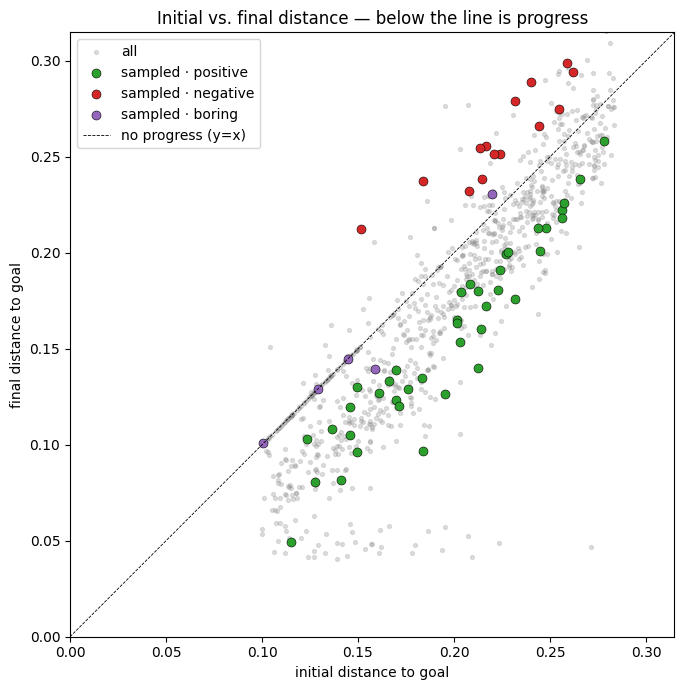

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(stats["initial_distance"], stats["final_distance"],
           s=8, alpha=0.25, color="#888888", label="all")
for cat in ["positive", "negative", "boring"]:
  sub = sampled[sampled["category"] == cat]
  ax.scatter(sub["initial_distance"], sub["final_distance"],
             s=42, color=colors[cat], edgecolor="black", linewidth=0.4,
             label=f"sampled · {cat}")

lim = max(stats["initial_distance"].max(), stats["final_distance"].quantile(0.99))
ax.plot([0, lim], [0, lim], color="black", linewidth=0.6, linestyle="--",
        label="no progress (y=x)")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("initial distance to goal")
ax.set_ylabel("final distance to goal")
ax.set_title("Initial vs. final distance — below the line is progress")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

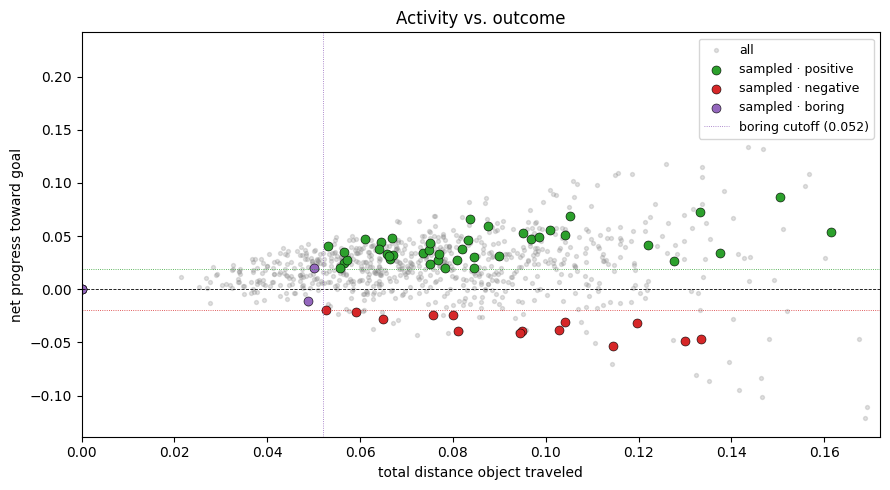

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(stats["distance_moved"], stats["net_progress"],
           s=8, alpha=0.25, color="#888888", label="all")
for cat in ["positive", "negative", "boring"]:
  sub = sampled[sampled["category"] == cat]
  ax.scatter(sub["distance_moved"], sub["net_progress"],
             s=42, color=colors[cat], edgecolor="black", linewidth=0.4,
             label=f"sampled · {cat}")

ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.axhline(PROGRESS_THRESH, color="#2ca02c", linewidth=0.6, linestyle=":")
ax.axhline(-PROGRESS_THRESH, color="#d62728", linewidth=0.6, linestyle=":")
ax.axvline(boring_thresh, color="#9467bd", linewidth=0.6, linestyle=":",
           label=f"boring cutoff ({boring_thresh:.3f})")

x_hi = np.percentile(stats["distance_moved"], 99)
ax.set_xlim(0, x_hi)
ax.set_xlabel("total distance object traveled")
ax.set_ylabel("net progress toward goal")
ax.set_title("Activity vs. outcome")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

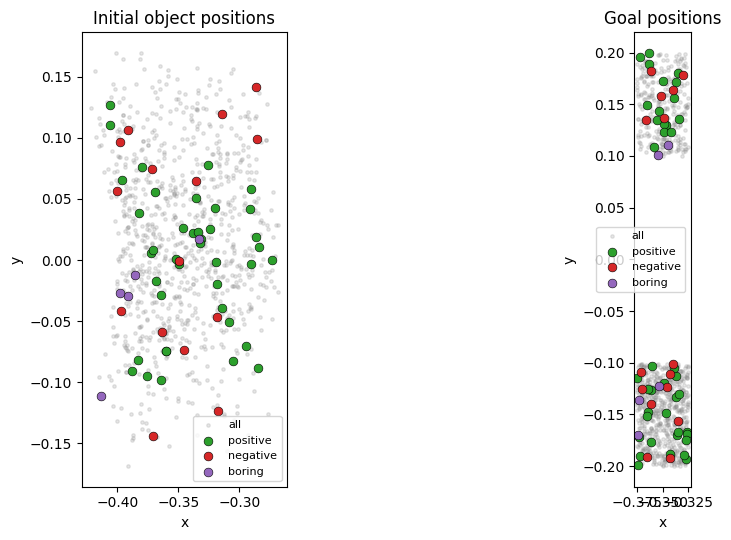

In [14]:
# Where do the sampled episodes start, and where are their goals?
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

init_all = np.stack(stats["initial_position"].to_numpy())
goal_all = np.stack(stats["goal_position"].to_numpy())

for ax, all_xy, title in [(axes[0], init_all, "Initial object positions"),
                          (axes[1], goal_all, "Goal positions")]:
  ax.scatter(all_xy[:, 0], all_xy[:, 1], s=6, alpha=0.2, color="#888888", label="all")
  for cat in ["positive", "negative", "boring"]:
    sub = sampled[sampled["category"] == cat]
    xy = np.stack(sub[("initial_position" if "Initial" in title else "goal_position")].to_numpy())
    if len(xy):
      ax.scatter(xy[:, 0], xy[:, 1], s=40, color=colors[cat],
                 edgecolor="black", linewidth=0.4, label=cat)
  ax.set_title(title)
  ax.set_xlabel("x"); ax.set_ylabel("y")
  ax.set_aspect("equal")
  ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

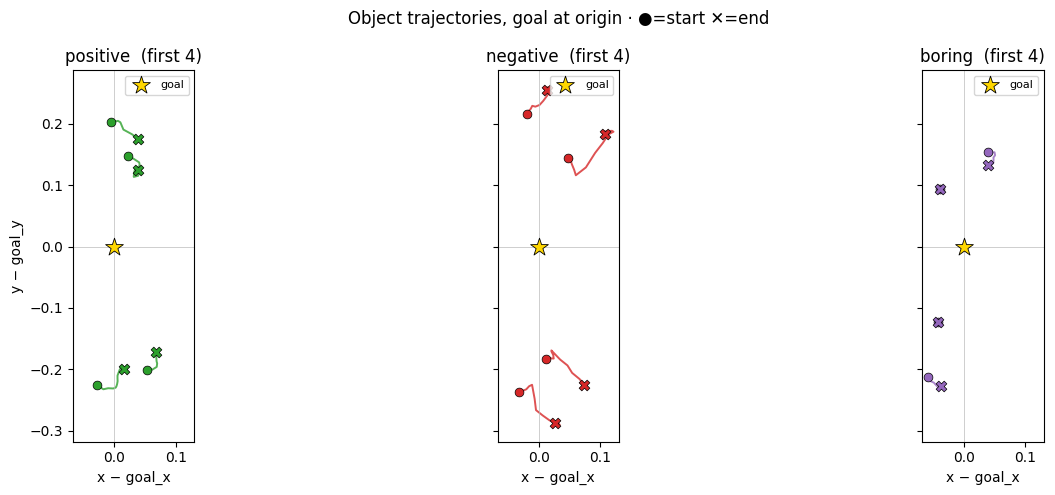

In [15]:
# Object trajectories (object_xy over time) for a handful of sampled episodes,
# normalized so the goal sits at the origin. Helps eyeball whether picks are
# qualitatively interesting.
def load_traj(path):
  xy, _, goal, _ = _load_episode_arrays(path)
  return xy - goal  # goal-centered

N_PER_CAT = 4
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for ax, cat in zip(axes, ["positive", "negative", "boring"]):
  sub = sampled[sampled["category"] == cat].head(N_PER_CAT)
  for _, r in sub.iterrows():
    traj = load_traj(Path(r["path"]))
    ax.plot(traj[:, 0], traj[:, 1], color=colors[cat], alpha=0.8, linewidth=1.4)
    ax.scatter(traj[0, 0], traj[0, 1], color=colors[cat], s=40, marker="o",
               edgecolor="black", linewidth=0.5, zorder=3)
    ax.scatter(traj[-1, 0], traj[-1, 1], color=colors[cat], s=60, marker="X",
               edgecolor="black", linewidth=0.5, zorder=3)
  ax.scatter([0], [0], marker="*", color="gold", s=180, edgecolor="black",
             linewidth=0.6, zorder=4, label="goal")
  ax.axhline(0, color="#bbbbbb", linewidth=0.5)
  ax.axvline(0, color="#bbbbbb", linewidth=0.5)
  ax.set_title(f"{cat}  (first {N_PER_CAT})")
  ax.set_aspect("equal")
  ax.legend(fontsize=8, loc="upper right")

axes[0].set_ylabel("y − goal_y")
for ax in axes:
  ax.set_xlabel("x − goal_x")
fig.suptitle("Object trajectories, goal at origin · ●=start ✕=end")
plt.tight_layout()
plt.show()

# sample for use

In [17]:
splits = sample_split([300, 20])
splits 

adjusted mix: {'positive': 40, 'negative': 15, 'boring': 5} -> weights {'positive': 44.5, 'negative': 9.94, 'boring': 5.56} (capacity: {'positive': 424, 'negative': 53, 'boring': 233})


[              filename                                        path  \
 0    episode-00083.rrd  ../data/generated-pushes/episode-00083.rrd   
 1    episode-00475.rrd  ../data/generated-pushes/episode-00475.rrd   
 2    episode-00250.rrd  ../data/generated-pushes/episode-00250.rrd   
 3    episode-00288.rrd  ../data/generated-pushes/episode-00288.rrd   
 4    episode-00797.rrd  ../data/generated-pushes/episode-00797.rrd   
 ..                 ...                                         ...   
 295  episode-00419.rrd  ../data/generated-pushes/episode-00419.rrd   
 296  episode-00464.rrd  ../data/generated-pushes/episode-00464.rrd   
 297  episode-00712.rrd  ../data/generated-pushes/episode-00712.rrd   
 298  episode-00594.rrd  ../data/generated-pushes/episode-00594.rrd   
 299  episode-00949.rrd  ../data/generated-pushes/episode-00949.rrd   
 
      total_steps  max_reward  outcome  initial_distance  final_distance  \
 0            150   -0.256413  timeout          0.278296        0.2584

In [20]:
splits[1]['filename'].tolist()

['episode-00886.rrd',
 'episode-00640.rrd',
 'episode-00907.rrd',
 'episode-00221.rrd',
 'episode-00055.rrd',
 'episode-00369.rrd',
 'episode-00724.rrd',
 'episode-00338.rrd',
 'episode-00114.rrd',
 'episode-00155.rrd',
 'episode-00558.rrd',
 'episode-00321.rrd',
 'episode-00474.rrd',
 'episode-00498.rrd',
 'episode-00099.rrd',
 'episode-00380.rrd',
 'episode-00361.rrd',
 'episode-00784.rrd',
 'episode-00218.rrd',
 'episode-00903.rrd']